![JohnSnowLabs](https://nlp.johnsnowlabs.com/assets/images/logo.png)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JohnSnowLabs/visual-nlp-workshop/blob/master/jupyter/Dicom/SparkOcrDicomPipelineBuilder.ipynb)

# DICOM De-identification Using Pretrained NER Pipelines

## Introduction

This notebook demonstrates how to use existing **pretrained NER pipelines** for DICOM de-identification.

It provides reusable **builder utilities** for integrating different pretrained clinical de-identification pipelines into a DICOM workflow. These utilities combine the selected NER pipeline with the required OCR, coordinate extraction, pixel redaction, and metadata de-identification stages to create an end-to-end de-identification pipeline.

### Pretrained NER Pipeline Support

You can use any compatible pretrained clinical de-identification pipeline based on your accuracy, performance, and entity-detection requirements.

> **Selecting a pipeline:** Visit the [**John Snow Labs Models Hub**](https://nlp.johnsnowlabs.com/models) and review the pipeline's model card before making a selection. The model card describes the entities targeted by the pipeline.

In [1]:
license = ""
secret = ""
nlp_secret = ""
aws_access_key = ""
aws_secret_key = ""

version = secret.split("-")[0]
spark_ocr_jar_path = "../../../target/scala-2.12"

## Start Visual NLP Spark Session

In [2]:
from sparkocr import start
import os

if license:
    os.environ['JSL_OCR_LICENSE'] = license
    os.environ['SPARK_NLP_LICENSE'] = license

if aws_access_key:
    os.environ['AWS_ACCESS_KEY'] = aws_access_key
    os.environ['AWS_SECRET_ACCESS_KEY'] = aws_secret_key

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

spark = start(secret=secret,
              nlp_secret=nlp_secret,
              jar_path=spark_ocr_jar_path,
              nlp_internal="6.2.2")

spark

Spark version: 3.4.1
Spark NLP version: 6.4.2
Spark NLP for Healthcare version: 6.4.1
Spark OCR version: 6.4.3rc2

:: loading settings :: url = jar:file:/usr/local/lib/python3.11/dist-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
com.johnsnowlabs.nlp#spark-nlp-gpu_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-77f66171-dd4c-402f-a670-6ba5e421cee9;1.0
	confs: [default]
	found com.johnsnowlabs.nlp#spark-nlp-gpu_2.12;6.4.2 in central
	found com.typesafe#config;1.4.2 in central
	found org.rocksdb#rocksdbjni;6.29.5 in central
	found com.amazonaws#aws-java-sdk-s3;1.12.500 in central
	found com.amazonaws#aws-java-sdk-kms;1.12.500 in central
	found com.amazonaws#aws-java-sdk-core;1.12.500 in central
	found commons-logging#commons-logging;1.1.3 in central
	found commons-codec#commons-codec;1.15 in central
	found org.apache.httpcomponents#httpclient;4.5.13 in central
	found org.apache.httpcomponents#httpcore;4.4.13 in central
	found software.amazon.ion#ion-java;1.0.2 in central
	found joda-time#joda-time;2.8.1 in central
	found com.amazonaws#jmespath-java;1.12.500 in central
	fou

In [3]:
import os
import json
import time
import sys
import shutil 
import pkg_resources 
import pandas as pd
from textwrap import dedent

from sparknlp.annotator import *
from sparknlp.base import *

import sparknlp_jsl
from sparknlp_jsl.annotator import *

import sparkocr
from sparkocr.transformers import *
from sparkocr.utils import *
from sparkocr.enums import *
from sparkocr.schemas import *

from pyspark.ml import PipelineModel, Pipeline
import pyspark.sql.functions as F
from pyspark.sql.types import *

print(f"Spark NLP version: {sparknlp.version()}")
print(f"Spark NLP internal version: {sparknlp_jsl.version()}")
print(f"Spark OCR version: {sparkocr.version()}")

/tmp/ipykernel_107988/495465704.py:6: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


Spark NLP version: 6.4.2
Spark NLP internal version: 6.4.1
Spark OCR version: 6.4.3rc2


## DICOM Pipeline Builders

Two builder classes are available for generating DICOM ingestion stages. The primary difference between them is the OCR engine used to extract text from DICOM images.

### VLM-Based OCR Pipeline

Uses `ocr_vlm_pipeline_builder` to build a VLM-based OCR pipeline.

```python
config["ocr_engine"] = "VLM"
```

### Non-VLM OCR Pipeline

Uses `ocr_non_vlm_pipeline_builder` to build a traditional CPU- or GPU-based OCR pipeline.

#### Hybrid-Based OCR

```python
config["ocr_engine"] = "V2"
```

#### CPU-Based OCR

```python
config["ocr_engine"] = "V3"
```

In [4]:
def ocr_vlm_pipeline_builder(config, logger):
    
    logger.info("Building VLM OCR pipeline")
    start_time = time.perf_counter()

    try:
        dicom_to_image = DicomToImageV3() \
            .setInputCols(["content"]) \
            .setOutputCol("image") \
            .setCompressionMode(config["compression_enabled"]) \
            .setKeepInput(False) \
            .setMemoryOptimized(True) \
            .setCompressionQuality(config["compression_quality"]) \
            .setScale(config["scale"]) \
            .setFrameLimit(config["frame_sampling"]) \
            .setFrameSamplingStrategy(FrameSamplingStrategy.CONSECUTIVE) \
            .setCompressImage(True) \
            .setFrameDimsCol("frame_dims")

        caption_assembler = DocumentAssembler() \
            .setInputCol("caption") \
            .setOutputCol("caption_document")

        schema_converter_assembler = ImageSchemaConverter() \
            .setInputCol("image") \
            .setOutputCol("image_assembler") \
            .setOutputSchema("assembler") \
            .setKeepInput(False)

        logger.info("Loading MedicalVisionLLM pretrained model")

        model = MedicalVisionLLM.pretrained("jsl-ocr-gguf-vlm1","en","clinical/ocr",) \
            .setInputCols(["caption_document", "image_assembler"]) \
            .setOutputCol("completions") \
            .setNGpuLayers(99) \
            .setNCtx(32768) \
            .setNParallel(1) \
            .setNBatch(2048) \
            .setNUbatch(1024) \
            .setNPredict(1024) \
            .setTemperature(0.01) \
            .setTopK(1) \
            .setTopP(1.0) \
            .setRepeatPenalty(1.03) \
            .setRepeatLastN(256) \
            .setStopStrings(["<｜hy_Assistant｜>","<｜hy_place▁holder▁no▁2｜>"]) \
            .setMinKeep(0) \
            .setNProbs(0) \
            .setBatchSize(1) \
            .setDisableLog(False)

        coordinate_extract = DocumentCoordinatesToText() \
            .setInputCol("completions") \
            .setImageDimsCol("frame_dims") \
            .setOutputCol("text") \
            .setPageMatrixCol("positions") \
            .setRegionCol("regions") \
            .setLineTolerance(5)

        stages = [
            dicom_to_image,
            caption_assembler,
            schema_converter_assembler,
            model,
            coordinate_extract,
        ]

        time_taken = time.perf_counter() - start_time
        logger.info("VLM OCR pipeline built with %d stages in %.2f seconds", len(stages), time_taken)

        return stages

    except Exception:
        logger.exception("Failed to build VLM OCR pipeline")
        raise


def ocr_non_vlm_pipeline_builder(config, logger):
    engine = config["ocr_engine"].lower()
    
    logger.info("Building non-VLM OCR pipeline: engine=%s, gpu=%s",engine,config["gpu"])
    
    start_time = time.perf_counter()

    try:
        dicom_to_image = DicomToImageV3() \
            .setInputCols(["content"]) \
            .setOutputCol("image") \
            .setCompressionMode(config["compression_enabled"]) \
            .setKeepInput(False) \
            .setMemoryOptimized(True) \
            .setCompressionQuality(config["compression_quality"]) \
            .setScale(config["scale"]) \
            .setFrameLimit(config["frame_sampling"]) \
            .setFrameSamplingStrategy(FrameSamplingStrategy.CONSECUTIVE) \
            .setCompressImage(False) \
            .setFrameDimsCol("frame_dims")

        logger.info("Loading image text-detection model")

        text_detector = ImageTextDetector.pretrained("image_text_detector_mem_opt", "en", "clinical/ocr") \
            .setInputCol("image") \
            .setOutputCol("text_regions") \
            .setScoreThreshold(0.7) \
            .setLinkThreshold(0.5) \
            .setWithRefiner(True) \
            .setTextThreshold(0.4) \
            .setSizeThreshold(-1) \
            .setUseGPU(config["gpu"]) \
            .setWidth(0)

        if engine == "v2":
            logger.info("Loading ImageToTextV2 model")

            ocr = ImageToTextV2.pretrained("ocr_large_printed_v2_opt", "en", "clinical/ocr") \
                .setRegionsColumn("text_regions") \
                .setInputCols(["image"]) \
                .setOutputCol("text") \
                .setOutputFormat(OcrOutputFormat.TEXT_WITH_POSITIONS) \
                .setGroupImages(False) \
                .setKeepInput(False) \
                .setUseGPU(config["gpu"]) \
                .setUseCaching(True)

        elif engine == "v3":
            logger.info("Configuring ImageToTextV3")

            ocr = ImageToTextV3() \
                .setInputCols(["image", "text_regions"]) \
                .setOutputCol("text")

        else:
            raise ValueError(f"Unsupported OCR engine: {config['ocr_engine']!r}. Expected 'v2', 'v3', or 'vlm'.")

        stages = [dicom_to_image, text_detector, ocr]

        time_taken = time.perf_counter() - start_time
        logger.info("Non-VLM OCR pipeline built with %d stages in %.2f seconds", len(stages), time_taken)

        return stages

    except Exception:
        logger.exception("Failed to build non-VLM OCR pipeline")
        raise

## NLP Pipeline Builder

The NLP pipeline builder performs pipeline surgery on a pretrained pipeline. It removes unnecessary stages while retaining the stages required for DICOM de-identification.

In [5]:
def nlp_builder(spark_session, pipeline, logger):
    logger.info("Building NLP subpipeline")
    start_time = time.perf_counter()

    try:
        stages = list(pipeline.model.stages)

        logger.info("Inspecting %d stages from the pretrained NLP pipeline", len(stages))

        stage_indices = {
            "ner_cutoff": [],
            "chunk_merger": [],
            "document_splitter": None,
            "sentence_detector": None,
        }

        for idx, stage in enumerate(stages):
            stage_name = stage.uid.rsplit("_", 1)[0].lower()

            logger.debug("NLP stage %d: name=%s, uid=%s", idx, stage_name, stage.uid)

            if stage_name in {"lightdeidentification", "deidentification"}:
                stage_indices["ner_cutoff"].append(idx)

            elif stage_name == "chunkmergemodel":
                stage_indices["chunk_merger"].append(idx)

            elif stage_name == "internaldocumentsplitter":
                stage_indices["document_splitter"] = idx

            elif stage_name in {"sentencedetector", "sentencedetectordlmodel"}:
                stage_indices["sentence_detector"] = idx

        logger.info("Discovered NLP stage indices: %s", stage_indices)

        if not stage_indices["ner_cutoff"]:
            raise ValueError("The pretrained pipeline does not contain a LightDeIdentification or DeIdentification stage.")

        if not stage_indices["chunk_merger"]:
            raise ValueError("The pretrained pipeline does not contain a ChunkMergeModel stage.")

        if (stage_indices["document_splitter"] is None and stage_indices["sentence_detector"] is None):
            
            raise ValueError(
                "The pretrained pipeline must contain at least one of: "
                "InternalDocumentSplitter, SentenceDetector, or SentenceDetectorDLModel.")

        chunk_merger_idx = max(stage_indices["chunk_merger"])
        cutoff_idx = min(stage_indices["ner_cutoff"])

        ner_chunk_output_col = stages[chunk_merger_idx].getOutputCol()
        new_stages = stages[:cutoff_idx]

        logger.info("Creating NLP subpipeline with %d stages; NER output column=%s",len(new_stages), ner_chunk_output_col)

        nlp_pipeline = Pipeline(stages=new_stages)
        empty_data = spark_session.createDataFrame([[""]], ["text"])
        nlp_model = nlp_pipeline.fit(empty_data)

        time_taken = time.perf_counter() - start_time
        logger.info("NLP subpipeline built in %.2f seconds", time_taken)

        return ner_chunk_output_col, nlp_model

    except Exception:
        logger.exception("Failed to build NLP subpipeline")
        raise

## Main Builder Method

In [6]:
def dicom_pipeline_builder(spark_session, config, intermediate_result, pretrained_pipeline, dicom_metadata_deid=None):
    """
    Build the complete DICOM OCR and de-identification pipeline.

    Combines DICOM image extraction, OCR, clinical NLP entity detection, and
    coordinate extraction. When ``intermediate_result`` is enabled, the
    pipeline also redacts detected pixel regions and de-identifies metadata.

    Parameters
    ----------
    spark_session: SparkSession
        SparkSession 
    config: dict
        Pipeline configuration containing OCR, image-processing, redaction,
        and metadata de-identification settings.
    intermediate_result: bool
        If True, include DicomDrawRegions and DicomMetadataDeidentifier.
        If False, end the pipeline after PositionFinder.
    pretrained_pipeline: PretrainedPipeline
        Pretrained Spark NLP healthcare de-identification pipeline.
    dicom_metadata_deid : DicomMetadataDeIdentifier
        Defaults to None, Uses a default DicomMetadataDeIdentifier
        As this stage is highly configurable, you can pass your own version of 
        DicomMetadataDeIdentifier. 

    Returns
    -------
    PipelineModel
        Configured DICOM OCR and de-identification pipeline.
    """
    import logging
    
    logger = logging.getLogger("dicom_deidentification_pipeline")

    if not logger.handlers:
        handler = logging.StreamHandler()
        handler.setFormatter(
            logging.Formatter(
                "%(asctime)s | %(levelname)s | %(name)s | %(message)s"
            )
        )
        logger.addHandler(handler)
    
    logger.setLevel(logging.INFO)
    logger.propagate = False
    
    logger.info(
        "Building DICOM de-identification pipeline: "
        "ocr_engine=%s, intermediate_result=%s",
        config["ocr_engine"],
        intermediate_result,
    )
    start_time = time.perf_counter()

    try:
        if config["ocr_engine"].lower() == "vlm":
            ingestion_stages = ocr_vlm_pipeline_builder(config, logger)
        else:
            ingestion_stages = ocr_non_vlm_pipeline_builder(config, logger)

        ner_output, nlp_pipeline = nlp_builder(spark_session, pretrained_pipeline, logger)

        position_finder = PositionFinder() \
            .setInputCols([ner_output]) \
            .setOutputCol("coordinates") \
            .setPageMatrixCol("positions") \
            .setIgnoreSchema(True) \
            .setOcrScaleFactor(1.0)

        draw_regions = DicomDrawRegions() \
            .setInputCol("path") \
            .setInputRegionsCol("coordinates") \
            .setOutputCol("dicom_pixel_cleaned") \
            .setAggCols(["path"]) \
            .setKeepInput(True) \
            .setScaleFactor(1 / config["scale"])
        
        if dicom_metadata_deid is None:
            
            dicom_deidentifier = DicomMetadataDeidentifier() \
                .setInputCols(["dicom_pixel_cleaned"]) \
                .setOutputCol("dicom_final_cleaned") \
                .setStrategyFile(config["strategy_file_path"]) \
                .setRemovePrivateTags(config["remove_private_tags"])
        else:
            dicom_deidentifier = dicom_metadata_deid

        original_metadata = DicomToMetadata() \
            .setInputCol("path") \
            .setOutputCol("metadata_original") \
            .setKeepInput(True) \
            .setExtractTagForNer(False)

        final_metadata = DicomToMetadata() \
            .setInputCol("dicom_final_cleaned") \
            .setOutputCol("metadata_final") \
            .setKeepInput(True) \
            .setExtractTagForNer(False)

        final_stages = [
            *ingestion_stages,
            nlp_pipeline,
            position_finder,
        ]

        if not intermediate_result:
            logger.info("Adding pixel redaction and metadata de-identification stages")
            
            final_stages.extend([
                draw_regions,
                dicom_deidentifier,
                original_metadata,
                final_metadata
            ])
        else:
            logger.info("Intermediate result disabled; returning pipeline through PositionFinder")

        pipeline_model = PipelineModel(stages=final_stages)

        time_taken = time.perf_counter() - start_time
        logger.info("DICOM pipeline built with %d stages in %.2f seconds", len(final_stages), time_taken)

        return pipeline_model

    except Exception:
        logger.exception("Failed to build DICOM pipeline")
        raise

## Most Up-to-Date NER Pipelines

Below are some of the most up-to-date NER pipelines available for clinical de-identification.

For pipeline details, benchmarks, and model cards, refer to the [Most Up to Date Ner Pipeline](https://nlp.johnsnowlabs.com/docs/en/benchmark#clinical-de-identification--most-up-to-date-pipelines).

In [7]:
pipeline_names = [
    "clinical_deidentification_docwise_benchmark_optimized",
    "clinical_deidentification_docwise_benchmark_medium",
    "clinical_deidentification_docwise_benchmark_medium_v2",
    "clinical_deidentification_docwise_zeroshot_medium",
    "clinical_deidentification_docwise_SingleStage_zeroshot_medium",
    "clinical_deidentification_docwise_benchmark_large",
    "clinical_deidentification_docwise_benchmark_large_v2",
    "clinical_deidentification_docwise_zeroshot_large",
    "clinical_deidentification_docwise_SingleStage_zeroshot_large",
]

## Metadata Configuration

The metadata configuration options are used by `DicomMetadataDeIdentifier`.

If `dicom_metadata_deid=None`, the pipeline builder creates and configures the metadata de-identification stage using these options.

- `remove_private_tags`: When set to `True`, removes all private DICOM tags.
- `strategy_file_path`: Specifies the path to the metadata de-identification strategy file.

## Pixel Configuration

The pixel configuration options are primarily used by `DicomToImageV3`. The `scale` option is shared by `DicomToImageV3` and `DicomDrawRegions`. 

For more information about configuring `DicomToImageV3`, refer to the `SparkOcrDicomToImageV3.ipynb` example notebook. 

For more information about configuring `DicomDrawRegions`, refer to the `SparkOcrDicomDrawRegions.ipynb` example notebook.

### `scale`

Controls the scale of the extracted DICOM image.

- A value less than `1.0` scales the image down.
- A value greater than `1.0` scales the image up.
- A value of `1.0` preserves the original dimensions.


### `frame_sampling`

Controls how many frames are processed from a multi-frame DICOM file.

For example, if a DICOM file contains 500 frames and `frame_sampling` is set to `5`, only the first five frames are processed. This can significantly reduce the de-identification processing time.


### `compression_quality`

Controls the image compression quality during DICOM image extraction.
This option is applied only when compression is enabled.

### `compression_enabled`

Controls when image compression is applied.

Supported values are:

- `"enabled"`: Compression is always applied.
- `"disabled"`: Compression is not applied, and `compression_quality` is ignored.
- `"auto"`: Compression is applied automatically based on the image's megapixel count.

## Other Configuration

### `gpu`

Controls whether GPU acceleration is used by OCR-based pipeline stages.

Recommended settings:

| OCR engine | Recommended `gpu` value | Notes |
|---|---:|---|
| `VLM` | `True` | Can run on CPU, but GPU is recommended for optimal performance. |
| `V2` | `True` | Can run on CPU, but GPU is recommended for optimal performance. |
| `V3` | `False` | Designed for CPU-based OCR processing. |

In [8]:
strategy_file_path = pkg_resources.resource_filename('sparkocr', 'resources/ocr/dicom/midi_b_strategy_with_tcia.csv')

config = {

    ### Metadata Configurations
    "remove_private_tags": True,
    "strategy_file_path": strategy_file_path,

    ### Pixel Configurations
    "scale": 0.75,
    "frame_sampling": 5,
    "compression_quality": 80,

    # Compression ["enabled", "disabled", "auto"]
    "compression_enabled": "enabled",

    # GPU [True, False]
    "gpu": True,

    # OCR Engine can be [VLM, V2, V3]
    "ocr_engine": "VLM"
}

## Load Dicom Data

In [ ]:
vision_prompt = "Detect and recognize text in the image, and output the text coordinates in a formatted manner."

path = "./../data/dicom/midib/TCIA-MIDI-B-Synthetic-Test_20250502___1.2.714.0.0.7426654.9.695.1102170333010371365___1-1.dcm"

df = spark.read.format("binaryFile").load(path).withColumn("caption", F.lit(vision_prompt))

df.columns

['path', 'modificationTime', 'length', 'content', 'caption']

In [10]:
from sparknlp.pretrained import PretrainedPipeline

deid_pipeline = PretrainedPipeline(pipeline_names[1], "en", "clinical/models")

ocr_pipe = dicom_pipeline_builder(spark_session=spark, 
                                  config=config, 
                                  intermediate_result=False, 
                                  pretrained_pipeline=deid_pipeline,
                                  dicom_metadata_deid=None)

clinical_deidentification_docwise_benchmark_medium download started this may take some time.
Approx size to download 2.3 GB
[ | ]clinical_deidentification_docwise_benchmark_medium download started this may take some time.
Approximate size to download 2.3 GB
Download done! Loading the resource.
[ / ]

[ \ ]

[ | ]

[OK!]


2026-08-05 13:38:18,322 | INFO | dicom_deidentification_pipeline | Building DICOM de-identification pipeline: ocr_engine=VLM, intermediate_result=False
2026-08-05 13:38:18,324 | INFO | dicom_deidentification_pipeline | Building VLM OCR pipeline
2026-08-05 13:38:25,454 | INFO | dicom_deidentification_pipeline | Loading MedicalVisionLLM pretrained model


jsl-ocr-gguf-vlm1 download started this may take some time.
Approximate size to download 1.5 GB
jsl-ocr-gguf-vlm1 download started this may take some time.
Approximate size to download 1.5 GB
Download done! Loading the resource.
Extracted 'libjllama.so' to '/tmp/libjllama.so'


ggml_cuda_init: found 1 CUDA devices (Total VRAM: 45498 MiB):
  Device 0: NVIDIA A40, compute capability 8.6, VMM: yes, VRAM: 45498 MiB
2026-08-05 13:38:50,296 | INFO | dicom_deidentification_pipeline | VLM OCR pipeline built with 5 stages in 31.97 seconds
2026-08-05 13:38:50,297 | INFO | dicom_deidentification_pipeline | Building NLP subpipeline
2026-08-05 13:38:50,298 | INFO | dicom_deidentification_pipeline | Inspecting 37 stages from the pretrained NLP pipeline
2026-08-05 13:38:50,300 | INFO | dicom_deidentification_pipeline | Discovered NLP stage indices: {'ner_cutoff': [35, 36], 'chunk_merger': [13, 34], 'document_splitter': 1, 'sentence_detector': None}
2026-08-05 13:38:50,301 | INFO | dicom_deidentification_pipeline | Creating NLP subpipeline with 35 stages; NER output column=ner_chunk
2026-08-05 13:38:50,415 | INFO | dicom_deidentification_pipeline | NLP subpipeline built in 0.12 seconds
2026-08-05 13:38:51,414 | INFO | dicom_deidentification_pipeline | Adding pixel redaction 

In [11]:
result = ocr_pipe.transform(df).cache()
result.columns

/usr/local/lib/python3.11/dist-packages/pyspark/sql/dataframe.py:169: UserWarning: DataFrame.sql_ctx is an internal property, and will be removed in future releases. Use DataFrame.sparkSession instead.
  warnings.warn(


['exception',
 'dicom_final_cleaned',
 'path',
 'external_mapping',
 'metadata_original',
 'metadata_final']

13:39:11, INFO Run DicomToImageV3                                   (0 + 1) / 1]
13:39:21, INFO DicomToImageV3: Number of frames: 1
13:39:21, INFO DicomToImageV3: Number of frames To Extract: 5
13:39:21, INFO DicomToImageV3: Extracting First Frame.
13:39:21, INFO Error during overlay extraction: Traceback (most recent call last):
File "/usr/local/lib/python3.11/dist-packages/sparkocr/transformers/dicom/dicom_to_image_v3.py", line 301, in add_image
arr = arr + ds.overlay_array(0x6000)
^^^^^^^^^^^^^^^^^^^^^^^^
return get_overlay_array(self, group)
^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
raise AttributeError(
AttributeError: Unable to convert the overlay data as the following required elements are missing from the dataset: OverlayData, OverlayBitsAllocated, OverlayRows, OverlayColumns
Using CUDA
2026-08-05 13:39:30.424252413 [W:onnxruntime:, transformer_memcpy.cc:111 ApplyImpl] 45 Memcpy nodes are added to the graph main_graph for CUDAExecutionProvider. It might have negative impact on performance

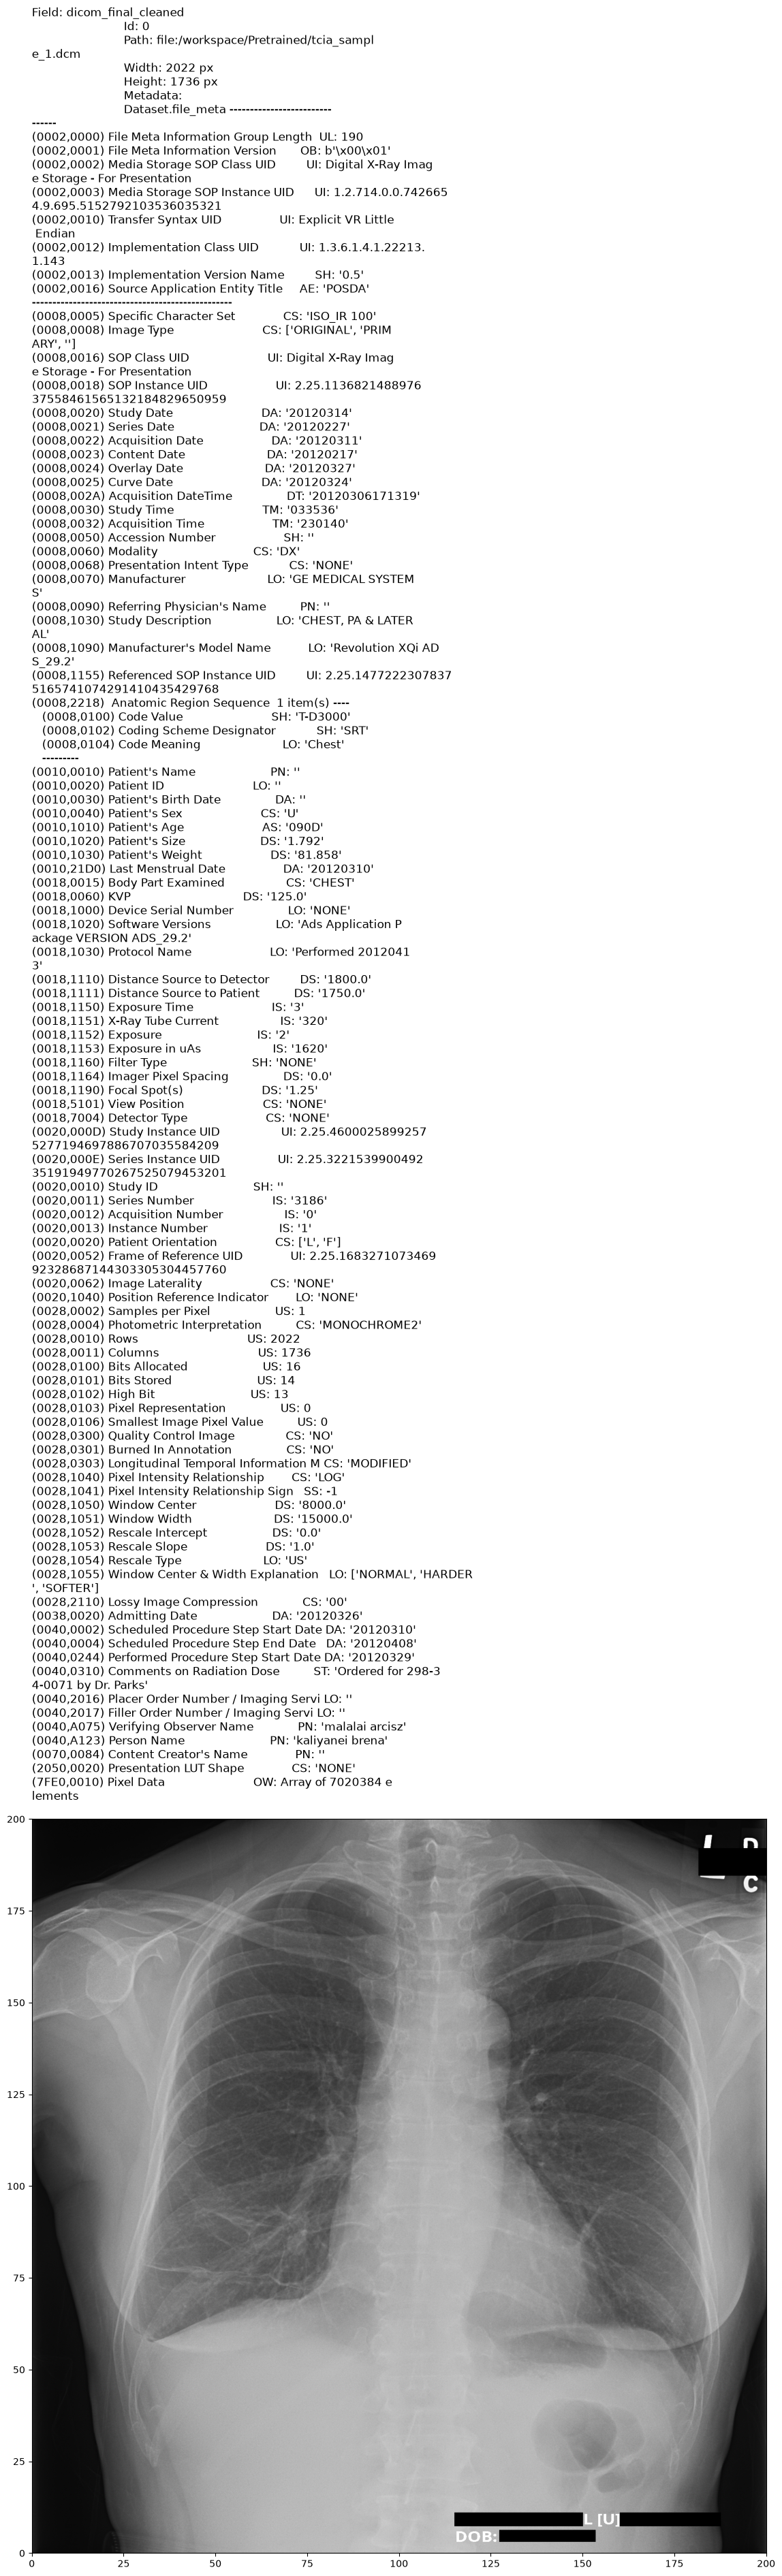

In [12]:
display_dicom(result, "dicom_final_cleaned")

## Custom DICOM Metadata De-identification

Here, we create a custom instance of `DicomMetadataDeIdentifier` with private tag removal enabled.

We also configure the stage to remove DICOM overlay tags from the `60xx` groups.

For more information about configuring `DicomMetadataDeIdentifier`, refer to the `SparkOcrMetadataDeIdentification` example notebook.

In [13]:
csv_group_data = dedent("""\
    Tags,VR,Name,Status,Action,Option
    "(0060,)",GROUP,None,,delete,
""")

dicom_deidentifier = DicomMetadataDeidentifier() \
    .setInputCols(["dicom_pixel_cleaned"]) \
    .setOutputCol("dicom_final_cleaned") \
    .setStrategyFile(strategy_file_path) \
    .setRemovePrivateTags(True) \
    ._set(groupStrategyFileContent=csv_group_data)

from sparknlp.pretrained import PretrainedPipeline

deid_pipeline = PretrainedPipeline(pipeline_names[2], "en", "clinical/models")

ocr_pipe = dicom_pipeline_builder(spark_session=spark, 
                                  config=config, 
                                  intermediate_result=False, 
                                  pretrained_pipeline=deid_pipeline,
                                  dicom_metadata_deid=dicom_deidentifier)

clinical_deidentification_docwise_benchmark_medium_v2 download started this may take some time.
Approx size to download 2.4 GB
[ | ]

clinical_deidentification_docwise_benchmark_medium_v2 download started this may take some time.
Approximate size to download 2.4 GB
Download done! Loading the resource.


[ \ ]

[ \ ]

[OK!]


2026-08-05 13:41:16,364 | INFO | dicom_deidentification_pipeline | Building DICOM de-identification pipeline: ocr_engine=VLM, intermediate_result=False
2026-08-05 13:41:16,367 | INFO | dicom_deidentification_pipeline | Building VLM OCR pipeline
2026-08-05 13:41:16,391 | INFO | dicom_deidentification_pipeline | Loading MedicalVisionLLM pretrained model


jsl-ocr-gguf-vlm1 download started this may take some time.


2026-08-05 13:41:17,370 | INFO | dicom_deidentification_pipeline | VLM OCR pipeline built with 5 stages in 1.00 seconds
2026-08-05 13:41:17,372 | INFO | dicom_deidentification_pipeline | Building NLP subpipeline
2026-08-05 13:41:17,373 | INFO | dicom_deidentification_pipeline | Inspecting 37 stages from the pretrained NLP pipeline
2026-08-05 13:41:17,376 | INFO | dicom_deidentification_pipeline | Discovered NLP stage indices: {'ner_cutoff': [35, 36], 'chunk_merger': [10, 32, 33, 34], 'document_splitter': 1, 'sentence_detector': None}
2026-08-05 13:41:17,377 | INFO | dicom_deidentification_pipeline | Creating NLP subpipeline with 35 stages; NER output column=ner_chunk


Approximate size to download 1.5 GB


2026-08-05 13:41:17,507 | INFO | dicom_deidentification_pipeline | NLP subpipeline built in 0.13 seconds
2026-08-05 13:41:18,261 | INFO | dicom_deidentification_pipeline | Adding pixel redaction and metadata de-identification stages
2026-08-05 13:41:18,263 | INFO | dicom_deidentification_pipeline | DICOM pipeline built with 11 stages in 1.90 seconds


In [14]:
result = ocr_pipe.transform(df).cache()
result.columns

/usr/local/lib/python3.11/dist-packages/pyspark/sql/dataframe.py:169: UserWarning: DataFrame.sql_ctx is an internal property, and will be removed in future releases. Use DataFrame.sparkSession instead.
  warnings.warn(


['exception',
 'dicom_final_cleaned',
 'path',
 'external_mapping',
 'metadata_original',
 'metadata_final']

13:41:29, INFO Run DicomToImageV3                                   (0 + 1) / 1]
13:41:40, INFO DicomToImageV3: Number of frames: 1
13:41:40, INFO DicomToImageV3: Number of frames To Extract: 5
13:41:40, INFO DicomToImageV3: Extracting First Frame.
13:41:40, INFO Error during overlay extraction: Traceback (most recent call last):
File "/usr/local/lib/python3.11/dist-packages/sparkocr/transformers/dicom/dicom_to_image_v3.py", line 301, in add_image
arr = arr + ds.overlay_array(0x6000)
^^^^^^^^^^^^^^^^^^^^^^^^
return get_overlay_array(self, group)
^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
raise AttributeError(
AttributeError: Unable to convert the overlay data as the following required elements are missing from the dataset: OverlayData, OverlayBitsAllocated, OverlayRows, OverlayColumns
Using CUDA
2026-08-05 13:41:43.757868871 [W:onnxruntime:, transformer_memcpy.cc:111 ApplyImpl] 45 Memcpy nodes are added to the graph main_graph for CUDAExecutionProvider. It might have negative impact on performance

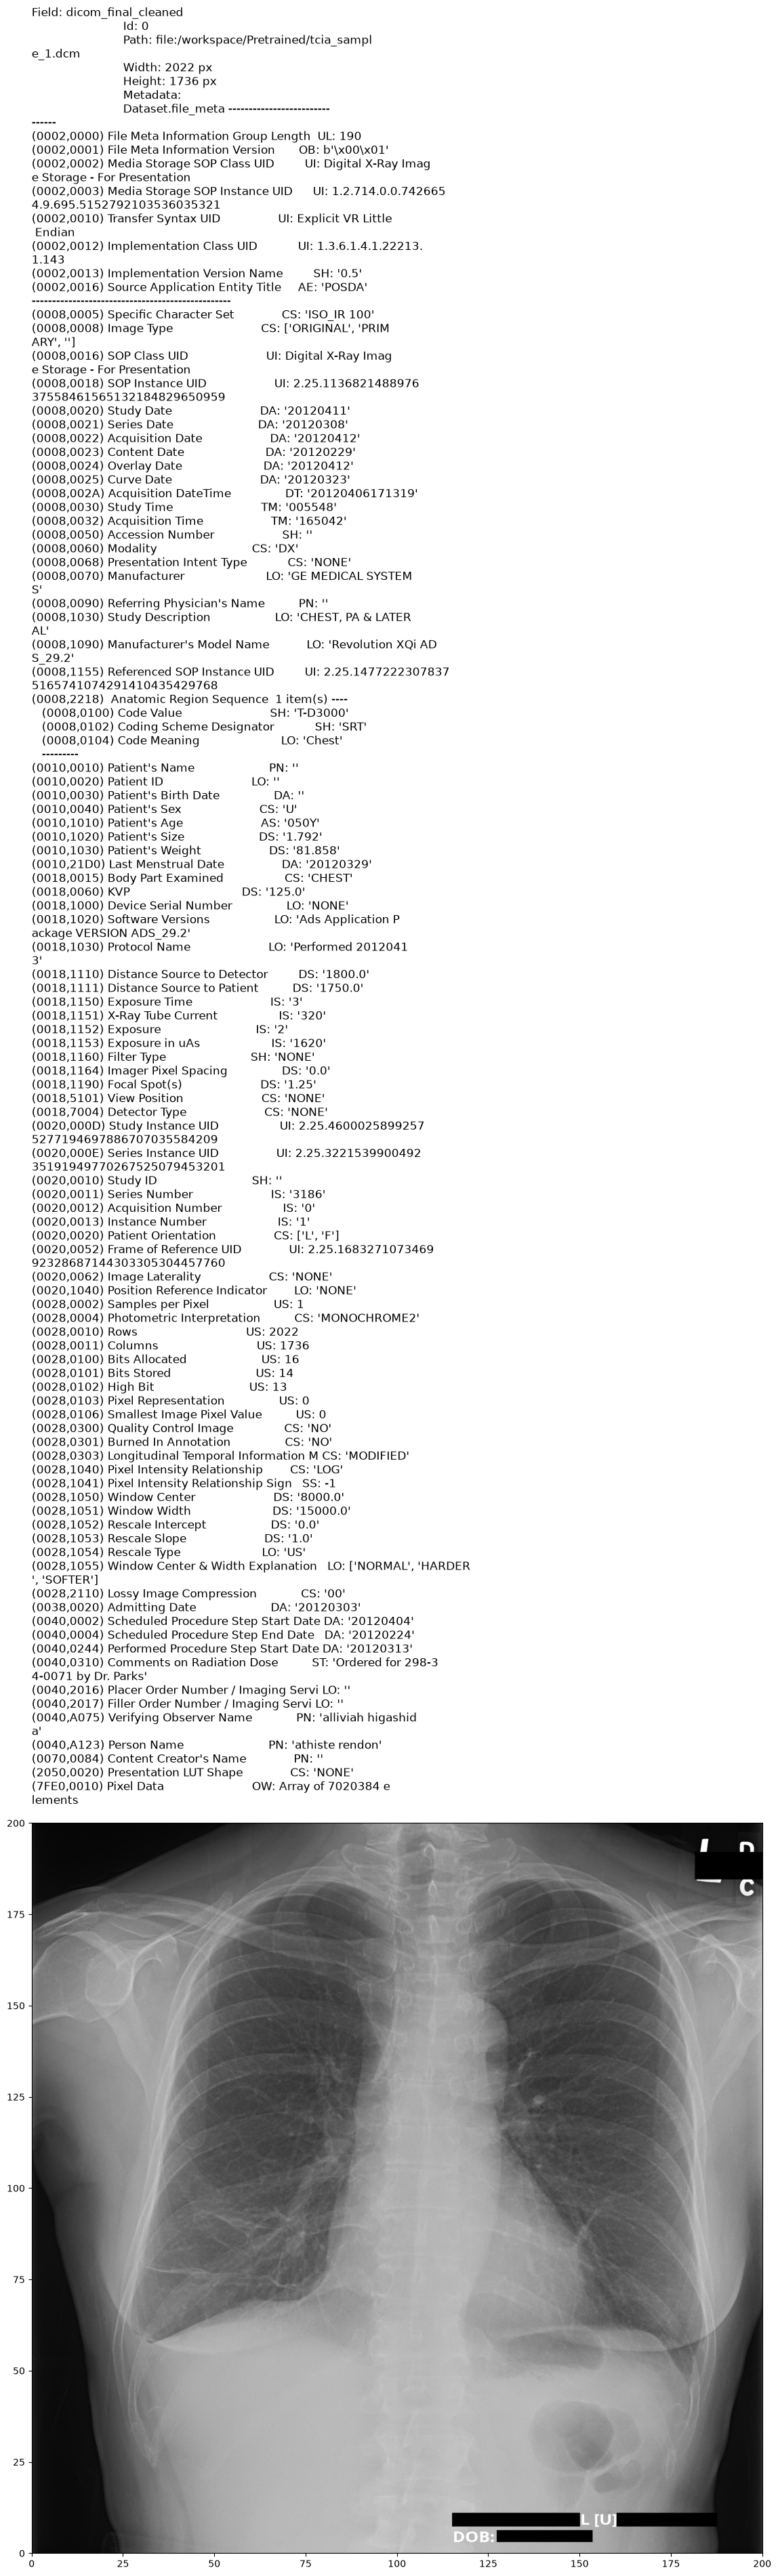

In [15]:
display_dicom(result, "dicom_final_cleaned")

## View Intermediate Stages

In [16]:
from sparknlp.pretrained import PretrainedPipeline

deid_pipeline = PretrainedPipeline(pipeline_names[3], "en", "clinical/models")

ocr_pipe = dicom_pipeline_builder(spark_session=spark, 
                                  config=config, 
                                  intermediate_result=True, 
                                  pretrained_pipeline=deid_pipeline,
                                  dicom_metadata_deid=dicom_deidentifier)

clinical_deidentification_docwise_zeroshot_medium download started this may take some time.
Approx size to download 754.6 MB
[ | ]

clinical_deidentification_docwise_zeroshot_medium download started this may take some time.
Approximate size to download 754.6 MB
Download done! Loading the resource.


[ — ]

[ \ ]

[OK!]


2026-08-05 13:43:18,828 | INFO | dicom_deidentification_pipeline | Building DICOM de-identification pipeline: ocr_engine=VLM, intermediate_result=True
2026-08-05 13:43:18,829 | INFO | dicom_deidentification_pipeline | Building VLM OCR pipeline
2026-08-05 13:43:18,851 | INFO | dicom_deidentification_pipeline | Loading MedicalVisionLLM pretrained model


jsl-ocr-gguf-vlm1 download started this may take some time.


2026-08-05 13:43:19,804 | INFO | dicom_deidentification_pipeline | VLM OCR pipeline built with 5 stages in 0.97 seconds
2026-08-05 13:43:19,805 | INFO | dicom_deidentification_pipeline | Building NLP subpipeline
2026-08-05 13:43:19,806 | INFO | dicom_deidentification_pipeline | Inspecting 30 stages from the pretrained NLP pipeline
2026-08-05 13:43:19,807 | INFO | dicom_deidentification_pipeline | Discovered NLP stage indices: {'ner_cutoff': [28, 29], 'chunk_merger': [25, 26, 27], 'document_splitter': 1, 'sentence_detector': None}
2026-08-05 13:43:19,808 | INFO | dicom_deidentification_pipeline | Creating NLP subpipeline with 28 stages; NER output column=ner_chunk


Approximate size to download 1.5 GB


2026-08-05 13:43:19,902 | INFO | dicom_deidentification_pipeline | NLP subpipeline built in 0.10 seconds
2026-08-05 13:43:20,668 | INFO | dicom_deidentification_pipeline | Intermediate result disabled; returning pipeline through PositionFinder
2026-08-05 13:43:20,670 | INFO | dicom_deidentification_pipeline | DICOM pipeline built with 7 stages in 1.84 seconds


In [17]:
result = ocr_pipe.transform(df).cache()
result.columns

['exception',
 'pagenum',
 'frame_dims',
 'path',
 'modificationTime',
 'length',
 'caption',
 'caption_document',
 'image_assembler',
 'completions',
 'text',
 'regions',
 'positions',
 'document',
 'splitter',
 'token_doc',
 'ner_chunk_zero_shot',
 'entity_icd10',
 'entity_ssn',
 'entity_account',
 'entity_dln',
 'entity_plate',
 'entity_vin',
 'entity_license',
 'entity_age',
 'entity_age_matcher',
 'entity_date',
 'entity_phone',
 'entity_medicalrecord',
 'entity_email',
 'entity_url',
 'entity_ip_address',
 'entity_zip',
 'entity_state',
 'entity_city',
 'entity_country',
 'entity_cpt_code',
 'entity_specimen',
 'deid_merged_ner_rulebased',
 'ner_chunk_raw',
 'ner_chunk',
 'coordinates']

### Check Exception caused while running the pipeline

In [18]:
result.select("path", "exception").show(10, False)

13:43:24, INFO Run DicomToImageV3                                   (0 + 1) / 1]
13:43:24, INFO DicomToImageV3: Number of frames: 1
13:43:24, INFO DicomToImageV3: Number of frames To Extract: 5
13:43:24, INFO DicomToImageV3: Extracting First Frame.
13:43:24, INFO Error during overlay extraction: Traceback (most recent call last):
File "/usr/local/lib/python3.11/dist-packages/sparkocr/transformers/dicom/dicom_to_image_v3.py", line 301, in add_image
arr = arr + ds.overlay_array(0x6000)
^^^^^^^^^^^^^^^^^^^^^^^^
return get_overlay_array(self, group)
^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
raise AttributeError(
AttributeError: Unable to convert the overlay data as the following required elements are missing from the dataset: OverlayData, OverlayBitsAllocated, OverlayRows, OverlayColumns
Using CUDA
2026-08-05 13:43:26.983209112 [W:onnxruntime:, transformer_memcpy.cc:111 ApplyImpl] 45 Memcpy nodes are added to the graph main_graph for CUDAExecutionProvider. It might have negative impact on performance

+--------------------------------------------+---------+
|path                                        |exception|
+--------------------------------------------+---------+
|file:/workspace/Pretrained/tcia_sample_1.dcm|         |
+--------------------------------------------+---------+



### Check Extracted Text From the Dicom Image

In [19]:
result.select("text").show(10, False)

+------------------------------------------------------+
|text                                                  |
+------------------------------------------------------+
|L\nD\nC\nONEAL DARRELL [U] 04.13.2012\nDOB: 02.19.1940|
+------------------------------------------------------+



### Check Extracted Text From the Dicom Image

In [20]:
result.select(F.explode("ner_chunk").alias("Extracted PHI")).show(10, False)

+-------------------------------------------------------------------------------------------------------------------------------------------------------+
|Extracted PHI                                                                                                                                          |
+-------------------------------------------------------------------------------------------------------------------------------------------------------+
|{chunk, 0, 18, L\nD\nC\nONEAL DARRELL, {entity -> PATIENT, confidence -> 0.99562055, ner_source -> ner_chunk_zero_shot, chunk -> 0, sentence -> 0}, []}|
|{chunk, 24, 33, 04.13.2012, {entity -> DATE, ner_source -> entity_date, chunk -> 1, sentence -> 0}, []}                                                |
|{chunk, 40, 49, 02.19.1940, {entity -> DATE, ner_source -> entity_date, chunk -> 2, sentence -> 0}, []}                                                |
+---------------------------------------------------------------------------

## End-To-End Example

In [21]:
from sparknlp.pretrained import PretrainedPipeline

deid_pipeline = PretrainedPipeline(pipeline_names[4], "en", "clinical/models")

ocr_pipe = dicom_pipeline_builder(spark_session=spark, 
                                  config=config, 
                                  intermediate_result=False, 
                                  pretrained_pipeline=deid_pipeline,
                                  dicom_metadata_deid=None)

clinical_deidentification_docwise_SingleStage_zeroshot_medium download started this may take some time.
Approx size to download 753.2 MB
[ | ]

clinical_deidentification_docwise_SingleStage_zeroshot_medium download started this may take some time.
Approximate size to download 753.2 MB
Download done! Loading the resource.


[ / ]

[OK!]


2026-08-05 13:43:46,580 | INFO | dicom_deidentification_pipeline | Building DICOM de-identification pipeline: ocr_engine=VLM, intermediate_result=False
2026-08-05 13:43:46,582 | INFO | dicom_deidentification_pipeline | Building VLM OCR pipeline
2026-08-05 13:43:46,602 | INFO | dicom_deidentification_pipeline | Loading MedicalVisionLLM pretrained model


jsl-ocr-gguf-vlm1 download started this may take some time.


2026-08-05 13:43:47,483 | INFO | dicom_deidentification_pipeline | VLM OCR pipeline built with 5 stages in 0.90 seconds
2026-08-05 13:43:47,486 | INFO | dicom_deidentification_pipeline | Building NLP subpipeline
2026-08-05 13:43:47,487 | INFO | dicom_deidentification_pipeline | Inspecting 6 stages from the pretrained NLP pipeline
2026-08-05 13:43:47,489 | INFO | dicom_deidentification_pipeline | Discovered NLP stage indices: {'ner_cutoff': [4, 5], 'chunk_merger': [3], 'document_splitter': 1, 'sentence_detector': None}
2026-08-05 13:43:47,490 | INFO | dicom_deidentification_pipeline | Creating NLP subpipeline with 4 stages; NER output column=ner_chunk


Approximate size to download 1.5 GB


2026-08-05 13:43:47,579 | INFO | dicom_deidentification_pipeline | NLP subpipeline built in 0.09 seconds
2026-08-05 13:43:48,260 | INFO | dicom_deidentification_pipeline | Adding pixel redaction and metadata de-identification stages
2026-08-05 13:43:48,261 | INFO | dicom_deidentification_pipeline | DICOM pipeline built with 11 stages in 1.68 seconds


In [22]:
result = ocr_pipe.transform(df).cache()
result.columns

['exception',
 'dicom_final_cleaned',
 'path',
 'external_mapping',
 'metadata_original',
 'metadata_final']

### Save Dicom To Disk

In [23]:
root_path = "./dicom_deid_output"

os.makedirs(root_path, exist_ok=True)

for item in result.select("path", "dicom_final_cleaned").toLocalIterator():
    data = item.asDict()
    filename = os.path.basename(data["path"])

    file_out_path = os.path.join(root_path, filename)

    with open(file_out_path, "wb") as dicom_out:
        dicom_out.write(data["dicom_final_cleaned"])

13:43:51, INFO Run DicomToImageV3
13:43:51, INFO DicomToImageV3: Number of frames: 1                  (0 + 1) / 1]
13:43:51, INFO DicomToImageV3: Number of frames To Extract: 5
13:43:51, INFO DicomToImageV3: Extracting First Frame.
13:43:51, INFO Error during overlay extraction: Traceback (most recent call last):
File "/usr/local/lib/python3.11/dist-packages/sparkocr/transformers/dicom/dicom_to_image_v3.py", line 301, in add_image
arr = arr + ds.overlay_array(0x6000)
^^^^^^^^^^^^^^^^^^^^^^^^
return get_overlay_array(self, group)
^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
raise AttributeError(
AttributeError: Unable to convert the overlay data as the following required elements are missing from the dataset: OverlayData, OverlayBitsAllocated, OverlayRows, OverlayColumns
Using CUDA
2026-08-05 13:43:54.228228189 [W:onnxruntime:, transformer_memcpy.cc:111 ApplyImpl] 45 Memcpy nodes are added to the graph main_graph for CUDAExecutionProvider. It might have negative impact on performance (including unabl

In [24]:
shutil.rmtree(root_path)